In [19]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

MODEL_NAME = "gpt-3.5-turbo-0125"
REPETITION = 1

FUNCTION_DESCRIPTIONS = [
    {
        "name": "get_code_snippet",
        "description": "This function takes a signature as input and returns the corresponding code snippet for the method or field.",
        "parameters": {
            "type": "object",
            "properties": {
                "signature": {
                    "type": "string",
                    "description": 'The signature of the method/field to retrieve the code snippet for. e.g. "com.example.myapp.MyClass.MyMethod(com.example.myapp.MyArgClass)" or "com.example.myapp.MyClass.MyField"',
                }
            },
            "required": ["signature"],
        },
    },
    {
        "name": "get_comments",
        "description": "This function takes a signature as input and returns JavaDoc documentation (if available) for the method or field.",
        "parameters": {
            "type": "object",
            "properties": {
                "signature": {
                    "type": "string",
                    "description": "The signature of the method/field to retrieve the documentation for.",
                }
            },
            "required": ["signature"],
        },
    },
]

DATA_DIR = os.path.join(
    "../"
    f"results/costfl/R_{REPETITION}/{MODEL_NAME}/",
)

In [20]:
def plot_boxplot(data, title="Distribution"):
    plt.figure(figsize=(6, 4))
    plt.boxplot(
        data,
        vert=True,
        patch_artist=True,
        showmeans=True
    )
    plt.ylabel("Runtime (seconds)")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

AVG: 9.500s
STD: 4.353s


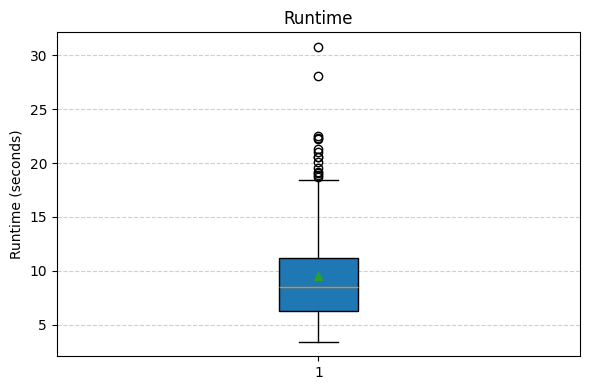

In [21]:
runtimes = []
for bug_name in sorted(os.listdir(f"{DATA_DIR}runtime/")):
    file_path = os.path.join(f"{DATA_DIR}runtime/", bug_name)
    if not os.path.isfile(file_path):
        continue

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        runtimes.append(data["runtime_sec"])

mean_val = np.mean(runtimes)
std_val = np.std(runtimes)

print(f"AVG: {mean_val:.3f}s")
print(f"STD: {std_val:.3f}s")

plot_boxplot(runtimes, "Runtime")

timewindow: 30
AVG: 0.097s
STD: 0.091s


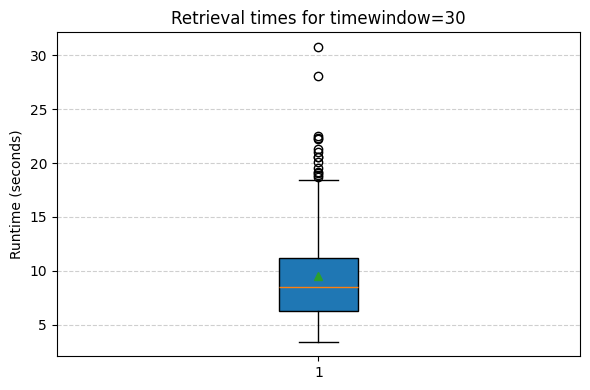


timewindow: 60
AVG: 0.153s
STD: 0.135s


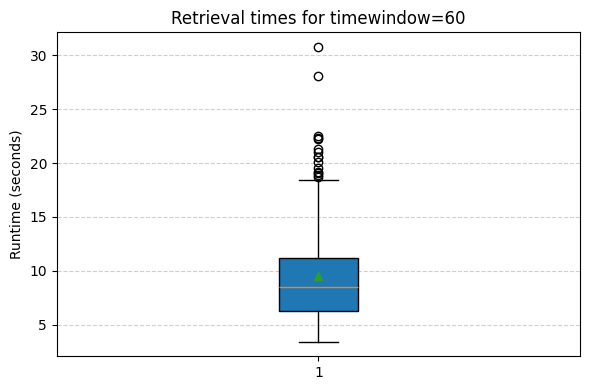


timewindow: 90
AVG: 0.205s
STD: 0.176s


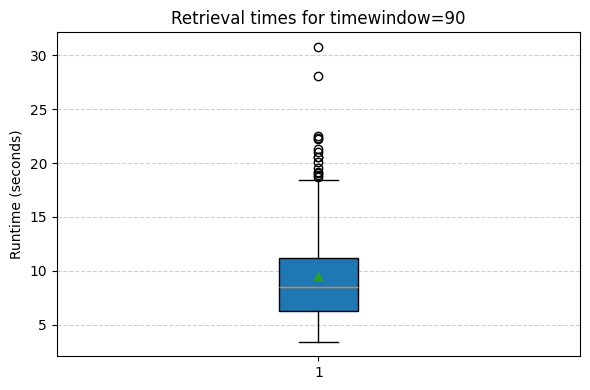

In [22]:
# relevant report retrieval
# 30days
# {'Cli': 66, 'Codec': 23, 'Collections': 3, 'Compress': 242, 'Csv': 36, 'JxPath': 60, 'Lang': 326, 'Math': 992}

# 60days
# {'Cli': 109, 'Codec': 41, 'Collections': 3, 'Compress': 381, 'Csv': 55, 'JxPath': 106, 'Lang': 653, 'Math': 2099}

# 90days
# {'Cli': 144, 'Codec': 61, 'Collections': 10, 'Compress': 535, 'Csv': 68, 'JxPath': 128, 'Lang': 921, 'Math': 3137}

def get_relevant_report_retrieval_times_data(timewindow):
    relevant_report_retrieval_times_file = f"../relevant_report_retrieval_times_timewindow_{timewindow}.json"
    with open(relevant_report_retrieval_times_file, "r", encoding="utf-8") as f:
        data = json.load(f)
        return list(data.values())

for timewindow in [30, 60, 90]:
    print(f"timewindow: {timewindow}")
    data = get_relevant_report_retrieval_times_data(timewindow)
    mean_val = np.mean(data)
    std_val = np.std(data)

    print(f"AVG: {mean_val:.3f}s")
    print(f"STD: {std_val:.3f}s")
    plot_boxplot(runtimes, f"Retrieval times for timewindow={timewindow}")
    print()
    

In [23]:
# https://developers.openai.com/cookbook/examples/how_to_count_tokens_with_tiktoken/#7-counting-tokens-for-chat-completions-with-tool-calls
def num_tokens_from_messages(messages, model):
    encoding = tiktoken.encoding_for_model(model)

    tokens_per_message = 3
    tokens_per_name = 1
    
    num_tokens = 0
    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            if value is None:
                continue
            if not isinstance(value, str):
                value = json.dumps(value)
            num_tokens += len(encoding.encode(value))
            if key == "name":
                num_tokens += tokens_per_name
    num_tokens += 3  # every reply is primed with <|start|>assistant<|message|>
    return num_tokens

def calc_tokens(functions, messages, model):
    func_init = 10
    prop_init = 3
    prop_key = 3
    enum_init = -3
    enum_item = 3
    func_end = 12

    encoding = tiktoken.encoding_for_model(model)
    
    func_token_count = 0
    if len(functions) > 0:
        for f in functions:
            func_token_count += func_init  # Add tokens for start of each function
            function = f
            f_name = function["name"]
            f_desc = function["description"]
            if f_desc.endswith("."):
                f_desc = f_desc[:-1]
            line = f_name + ":" + f_desc
            func_token_count += len(encoding.encode(line))  # Add tokens for set name and description
            if len(function["parameters"]["properties"]) > 0:
                func_token_count += prop_init  # Add tokens for start of each property
                for key in list(function["parameters"]["properties"].keys()):
                    func_token_count += prop_key  # Add tokens for each set property
                    p_name = key
                    p_type = function["parameters"]["properties"][key]["type"]
                    p_desc = function["parameters"]["properties"][key]["description"]
                    if "enum" in function["parameters"]["properties"][key].keys():
                        func_token_count += enum_init  # Add tokens if property has enum list
                        for item in function["parameters"]["properties"][key]["enum"]:
                            func_token_count += enum_item
                            func_token_count += len(encoding.encode(item))
                    if p_desc.endswith("."):
                        p_desc = p_desc[:-1]
                    line = f"{p_name}:{p_type}:{p_desc}"
                    func_token_count += len(encoding.encode(line))
        func_token_count += func_end
        
    messages_token_count = num_tokens_from_messages(messages, model)
    total_tokens = messages_token_count + func_token_count
    
    return total_tokens

AVG: 2347.722
STD: 756.603


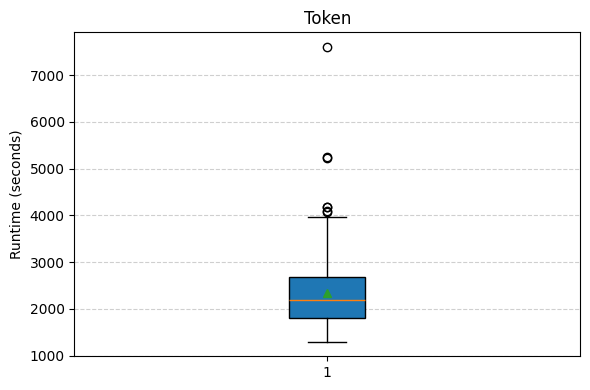

In [24]:
token_len = []
for bug_name in sorted(os.listdir(DATA_DIR)):
    file_path = os.path.join(DATA_DIR, bug_name)
    if not os.path.isfile(file_path):
        continue

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        messages = data["messages"]
        token_len.append(calc_tokens(FUNCTION_DESCRIPTIONS, messages, MODEL_NAME))

mean_val = np.mean(token_len)
std_val = np.std(token_len)

print(f"AVG: {mean_val:.3f}")
print(f"STD: {std_val:.3f}")

plot_boxplot(token_len, "Token")